<a href="https://colab.research.google.com/github/Malavika-2211/fds-experiments-250701409/blob/main/exp_6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving website_traffic.csv to website_traffic.csv


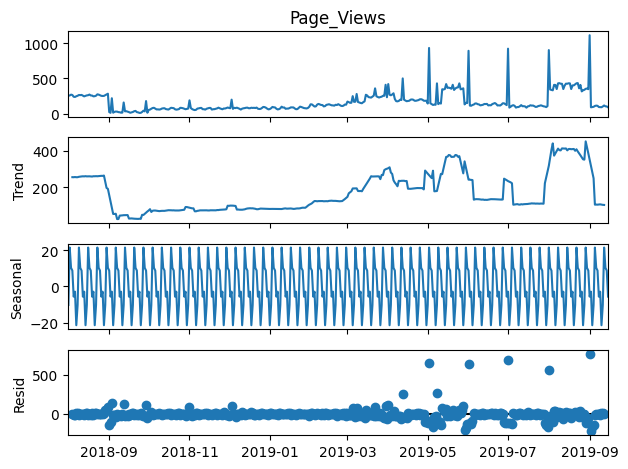

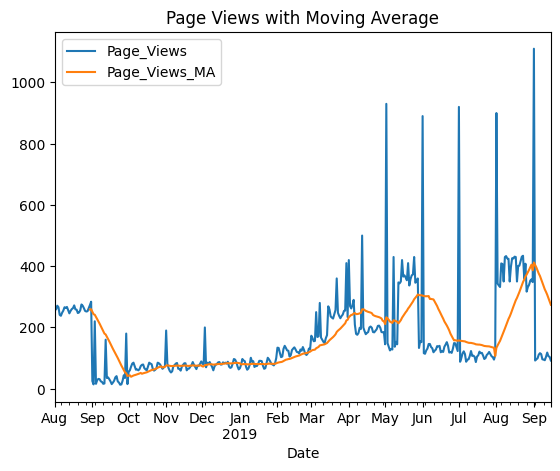

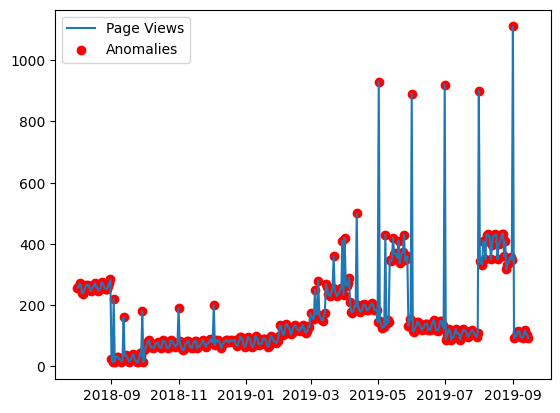

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from google.colab import files

uploaded = files.upload()

# Load dataset
data = pd.read_csv('website_traffic.csv', parse_dates=['Date'], index_col='Date')

# Time Series Decomposition
decomposition = seasonal_decompose(data['Page_Views'], model='additive')
decomposition.plot()
plt.show()

# Moving Average
data['Page_Views_MA'] = data['Page_Views'].rolling(window=30).mean()
data[['Page_Views', 'Page_Views_MA']].plot()
plt.title('Page Views with Moving Average')
plt.show()

# Anomaly Detection
data['Page_Views_Z'] = (data['Page_Views'] - data['Page_Views'].mean())
data['Page_Views'].std()
anomalies = data[data['Page_Views_Z'].abs() > 3]
plt.plot(data.index, data['Page_Views'], label='Page Views')
plt.scatter(anomalies.index, anomalies['Page_Views'], color='red', label='Anomalies')
plt.legend()
plt.show()